# Amplitude Modulation

`amplitude_modulation` multiplies a 1-D series by a piecewise amplitude envelope.
Change points are sampled along time, random amplitudes are drawn from
$\mathcal{N}(\texttt{amplitude\_mean}, \texttt{amplitude\_variation}^2)$, and the envelope
is interpolated (`linear` / `cubic` / `lagrange`). The result has the **same length**
as the input.

| Parameter | Default | Role |
| --- | --- | --- |
| `num_changepoints` | 5 | How many knots the envelope has (must be >= 2) |
| `amplitude_mean` | 1.0 | Mean of the random knot amplitudes |
| `amplitude_variation` | 1.0 | Spread of knot amplitudes |
| `interpolation_method` | `"linear"` | Envelope interpolant |
| `rng` / `seed` | `seed=42` | Reproducibility |

Below: an ARMA synthetic series and the bundled ETTh1 `OT` channel (first 512 steps).


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import amplitude_modulation

print("synth", synth.shape, "real", real.shape)

synth (512,) real (512,)


## Default effect on synthetic and real series


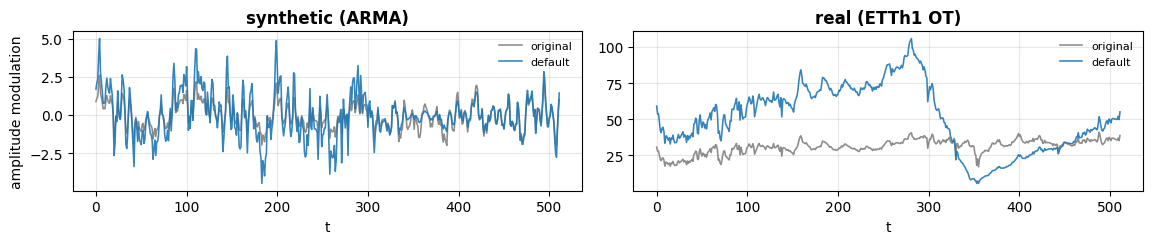

In [2]:
aug_s = amplitude_modulation(synth, rng=np.random.RandomState(1))
aug_r = amplitude_modulation(real, rng=np.random.RandomState(1))
overlay_pair(
    [synth, real],
    [[("default", aug_s)], [("default", aug_r)]],
    titles=["amplitude modulation"],
)
plt.show()

## Parameter effect

- More **changepoints** make the envelope wiggle faster.
- Larger **amplitude_variation** stretches peaks and compresses troughs more aggressively.
- **cubic** interpolation is smoother than **linear**; **lagrange** can overshoot at the knots.


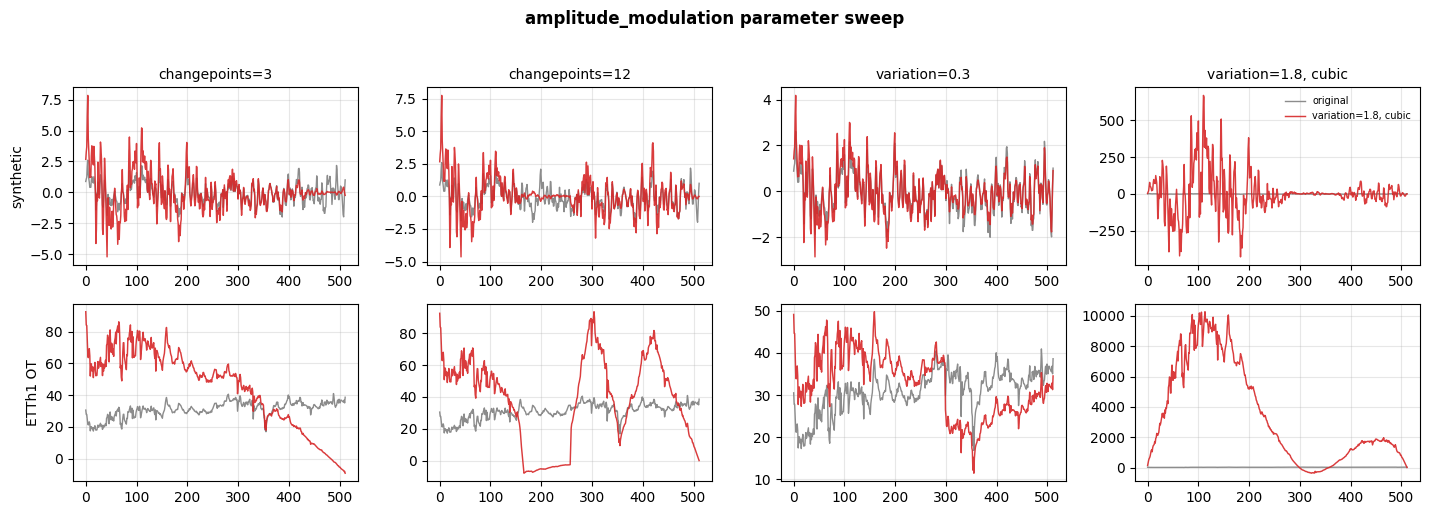

In [3]:
makers = [
    (
        "changepoints=3",
        lambda x: amplitude_modulation(
            x, num_changepoints=3, rng=np.random.RandomState(2)
        ),
    ),
    (
        "changepoints=12",
        lambda x: amplitude_modulation(
            x, num_changepoints=12, rng=np.random.RandomState(2)
        ),
    ),
    (
        "variation=0.3",
        lambda x: amplitude_modulation(
            x, amplitude_variation=0.3, rng=np.random.RandomState(2)
        ),
    ),
    (
        "variation=1.8, cubic",
        lambda x: amplitude_modulation(
            x,
            amplitude_variation=1.8,
            interpolation_method="cubic",
            rng=np.random.RandomState(2),
        ),
    ),
]
sweep_grid(
    [synth, real],
    ["synthetic", "ETTh1 OT"],
    makers,
    "amplitude_modulation parameter sweep",
)
plt.show()